# Employee attrition prediction using K-Nearest Neighbors

## Project overview
Employee attrition is an important business problem because employee turnover can increase hiring costs and reduce productivity. This project uses the K-Nearest Neighbors (KNN) algorithm to predict whether an employee is likely to leave the company based on workplace and performance-related variables.

## Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [2]:
df = pd.read_csv('recursos_humanos.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Exploratory data analysis (EDA)

### Dataset features

- `satisfaction_level`: Employee satisfaction level.
- `last_evaluation`: Score from the last performance evaluation.
- `number_project`: Number of projects assigned to the employee.
- `average_montly_hours`: Average monthly hours worked.
- `time_spend_company`: Number of years spent at the company.
- `Work_accident`: Whether the employee had a workplace accident.
- `promotion_last_5years`: Whether the employee was promoted in the last five years.
- `sales`: Department.
- `salary`: Salary category.
- `left`: Target variable indicating whether the employee left the company.

### Check the general structure of the dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


### Summary statistics

In [4]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Check the number of missing values in the dataset 

In [5]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

### Explore categorical features

In [6]:
df['sales'].unique()

<StringArray>
[      'sales',  'accounting',          'hr',   'technical',     'support',
  'management',          'IT', 'product_mng',   'marketing',       'RandD']
Length: 10, dtype: str

In [7]:
df['salary'].unique()

<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

## Data preprocessing

Categorical variables are encoded using one-hot encoding so that they can be used by the KNN classifier.

In [8]:
df_dummies = pd.get_dummies(df,drop_first = True)
# Print the new DataFrame's shape
print("Shape of df_dummies: {}".format(df_dummies.shape))
df_dummies['left'].value_counts()

Shape of df_dummies: (14999, 19)


left
0    11428
1     3571
Name: count, dtype: int64

In [9]:
df_dummies.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales_RandD                 bool
sales_accounting            bool
sales_hr                    bool
sales_management            bool
sales_marketing             bool
sales_product_mng           bool
sales_sales                 bool
sales_support               bool
sales_technical             bool
salary_low                  bool
salary_medium               bool
dtype: object

## Define features and target variable

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = np.asarray(df_dummies.drop('left',axis = 1))
y = np.asarray(df_dummies['left'])

## Train-test split

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.30,random_state = 42,stratify = y)
# Scale features
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Build KNN models

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)

    results.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

df_results = pd.DataFrame(results)
df_results

,k,Accuracy,Precision,Recall,F1 Score
0,1,0.961778,0.893263,0.953315,0.922313
1,2,0.958667,0.919431,0.905696,0.912512
2,3,0.946444,0.865961,0.916900,0.890703
3,4,0.947333,0.894886,0.882353,0.888575
4,5,0.939778,0.859712,0.892624,0.875859
5,6,0.945556,0.887430,0.883287,0.885353
6,7,0.941333,0.868493,0.887955,0.878116
7,8,0.942889,0.878253,0.882353,0.880298
8,9,0.939778,0.862319,0.888889,0.875402
9,10,0.941778,0.874191,0.882353,0.878253


The model with `k = 1` achieved the highest F1-score on the test set. Since the dataset is imbalanced, F1-score is more informative than accuracy because it balances precision and recall for the attrition class.

In [13]:
# Evaluate test error rates for different k values using the elbow method
test_error_rates = []
for k in range(1,21):
    knn_model = KNeighborsClassifier(n_neighbors = k)
    knn_model.fit(scaled_X_train,y_train)
    y_pred_test = knn_model.predict(scaled_X_test)
    test_error = 1-accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)

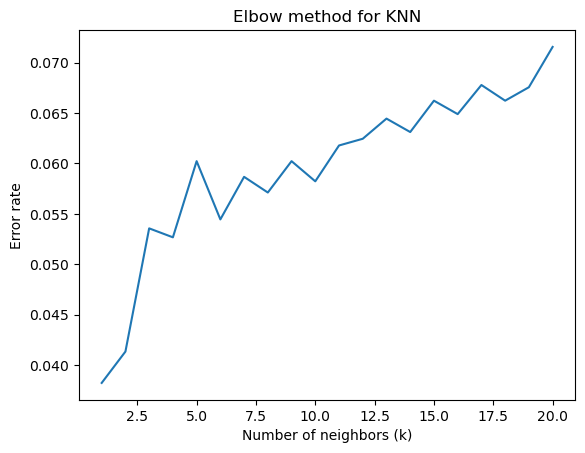

In [28]:
# Elbow method visualization
plt.plot(range(1,21),test_error_rates)
plt.ylabel('Error rate')
plt.xlabel('Number of neighbors (k)')
plt.title('Elbow method for KNN')
plt.savefig('knn_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

As `k` increases, the model becomes more general and may favor the majority class. In this dataset, most employees did not leave the company, so larger values of `k` can reduce sensitivity to the minority class. The model with `k = 1` has lower bias but higher variance.

## KNN model (k = 1)

In [15]:
knn_model = KNeighborsClassifier(n_neighbors = 1)

In [16]:
knn_model.fit(scaled_X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [17]:
knn_predictions = knn_model.predict(scaled_X_test)


## KNN model (k = 1) evaluation

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

In [19]:
cm = confusion_matrix(y_test,knn_predictions)
cm

array([[3307,  122],
       [  50, 1021]])

### Print classification report

In [20]:
print(classification_report(y_test,knn_predictions))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3429
           1       0.89      0.95      0.92      1071

    accuracy                           0.96      4500
   macro avg       0.94      0.96      0.95      4500
weighted avg       0.96      0.96      0.96      4500



### Confusion matrix visualization

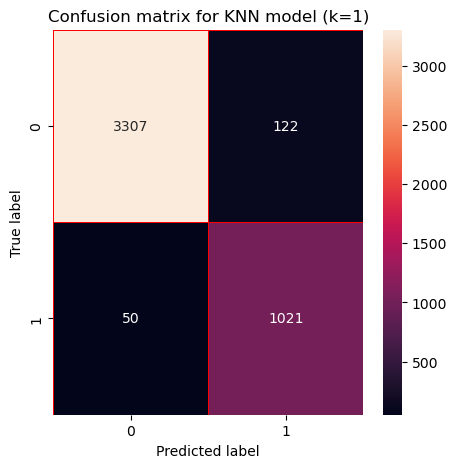

In [29]:
f, ax = plt.subplots(figsize = (5,5))
sns.heatmap(cm,annot = True,linewidths = 0.5, linecolor = 'red', fmt ='.0f',ax = ax)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix for KNN model (k=1)')
plt.savefig('knn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
#True positives = 1021
#True negatives = 3307
#False positives = 122
#False negatives = 50

correct_predictions = cm[0,0]+ cm[1,1]
incorrect_predictions = cm[0,1]+ cm[1,0]
accuracy_manual = correct_predictions/ (correct_predictions + incorrect_predictions)
print(np.round(accuracy_manual,2))

0.96


In [23]:
precision_stayed = cm[0,0]/(cm[0,0]+ cm[1,0])
print(np.round(precision_stayed,2))
# Precision for employees who stayed

0.99


In [24]:
precision_left = cm[1,1]/(cm[1,1]+ cm[0,1])
print(np.round(precision_left,2)) 
# Precision for employees who left
# This is relevant because the dataset is imbalanced.

0.89


### ROC curve visualization

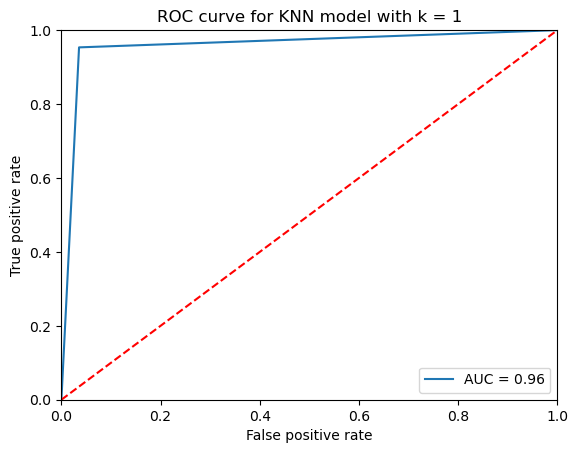

In [30]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
y_scores = knn_model.predict_proba(scaled_X_test)
fpr, tpr, threshold = roc_curve(y_test,y_scores[:,1])
roc_auc = auc(fpr,tpr)
plt.plot(fpr,tpr,label = 'AUC = %0.2f'% roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve for KNN model with k = 1')
plt.savefig('knn_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

The ROC curve shows a high true positive rate, indicating that the model performs well in identifying employees who left the company.

In [26]:
# Training set evaluation
y_train_pred = knn_model.predict(scaled_X_train)
print("Train F1:", f1_score(y_train, y_train_pred))

# Test set evaluation
print("Test F1 :", f1_score(y_test, knn_predictions))

Train F1: 1.0
Test F1 : 0.9223125564588979


## Conclusions

The K-Nearest Neighbors model achieved strong performance in predicting employee attrition. Among the evaluated values of `k`, the model with `k = 1` achieved the highest F1-score on the test set.

Because the dataset is imbalanced, F1-score was a useful metric for comparing models, as it balances precision and recall for the attrition class. The confusion matrix and classification report showed that the model demonstrates good discrimination between employees who stayed and employees who left the company. 

The model achieved a perfect F1-score on the training set, which suggests potential overfitting. However, the test F1-score remained high, indicating that the model still generalized well to unseen data.

The ROC curve also indicated strong classification performance. Future improvements could compare KNN with other classification algorithms, evaluate additional preprocessing techniques, or use cross-validation to reduce the risk of selecting a model that performs well on only one train-test split.